In [2]:
import networkx as nx
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
# Set the path to the file you'd like to load
file_path = "Synthetic_Financial_datasets_log.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sriharshaeedala/financial-fraud-detection-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/7r/9xprdm4d4y1dnghypxr2t42w0000gn/T/ipykernel_38808/541910546.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [4]:
# Get count of fraud by type
fraud_counts = (
    df[df['isFraud'] == 1]
    .groupby('type')
    .size()
    .reset_index(name='fraud_count')
)

# Get all transaction types
all_types = df[['type']].drop_duplicates()

# Merge to keep all types (even those with 0 fraud)
result = (
    all_types
    .merge(fraud_counts, on='type', how='left')
    .fillna({'fraud_count': 0})
    .sort_values('type')
    .reset_index(drop=True)
)

print(result)

       type  fraud_count
0   CASH_IN          0.0
1  CASH_OUT       4116.0
2     DEBIT          0.0
3   PAYMENT          0.0
4  TRANSFER       4097.0


In [5]:
df_edges = df[df['type'].isin(['CASH_OUT','TRANSFER'])]

G = nx.from_pandas_edgelist(
    df_edges,
    source='nameOrig',
    target='nameDest',
    edge_attr=['amount','isFraud'],
    create_using=nx.DiGraph()
)

In [6]:
import networkx as nx
import pandas as pd

# --- 1) Out-/In-/Node (total) degree centrality
out_deg_c = nx.out_degree_centrality(G)   # normalized by (n-1)
in_deg_c  = nx.in_degree_centrality(G)    # normalized by (n-1)
deg_c     = nx.degree_centrality(G)       # for DiGraph = in+out degree, normalized by (n-1)

# --- 2) Eigenvector centrality (Undirected)

ev_undirected = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000, tol=1e-06)

# --- 3) Assemble into a single DataFrame
nodes = list(G.nodes())
metrics = pd.DataFrame({'account': nodes})
metrics['out_degree'] = metrics['account'].map(out_deg_c).fillna(0)
metrics['in_degree']  = metrics['account'].map(in_deg_c).fillna(0)
metrics['node_degree'] = metrics['account'].map(deg_c).fillna(0)
metrics['eigenvector'] = metrics['account'].map(ev_undirected).fillna(0)

Positives (fraud-involved): 16382 | Negatives: 3261127

AUC summary (higher is better):
     metric  roc_auc   pr_auc
  in_degree 0.669774 0.010956
node_degree 0.599559 0.008875
 out_degree 0.327903 0.003986
eigenvector 0.290159 0.003562


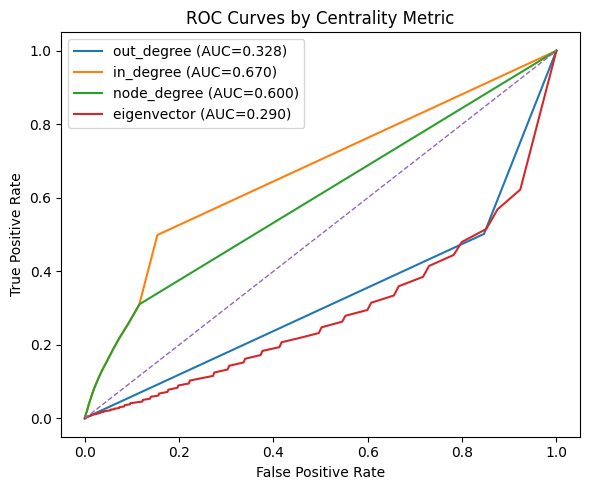

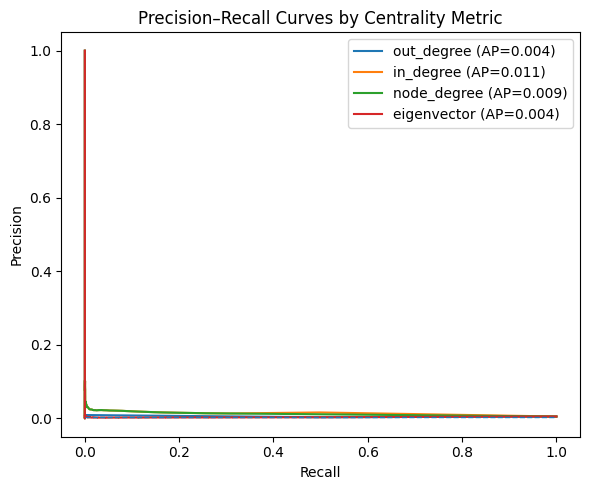

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

# --- 0) Select which metrics to evaluate ---
metric_cols = [
    'out_degree',
    'in_degree',
    'node_degree',
    'eigenvector',       # use your chosen eigenvector column
    # 'pagerank',        # include if available
    # 'hub', 'authority' # include if available
]

# --- 1) Prepare labels (y) ---
metrics['isFraudInvolved'] = metrics['account'].isin(set(df.loc[df['isFraud']==1,'nameOrig']) | set(df.loc[df['isFraud']==1,'nameDest']))
y = metrics['isFraudInvolved'].astype(int).values
pos = y.sum()
neg = (1 - y).sum()
print(f"Positives (fraud-involved): {pos} | Negatives: {neg}")

if pos == 0 or neg == 0:
    raise ValueError("Need both positive and negative examples for ROC/PR evaluation.")

# --- 2) Helper: convert raw metric to comparable scores (percentile ranks)
# ROC/PR are invariant to any monotonic transform, so rank-normalization is fine and handles heavy tails/ties.
def to_scores(series: pd.Series) -> np.ndarray:
    return series.fillna(0).rank(pct=True, ascending=False).values

# --- 3) Compute AUCs and curves for each metric ---
results = []
roc_curves = {}      # name -> (fpr, tpr)
pr_curves  = {}      # name -> (precision, recall)

for col in metric_cols:
    if col not in metrics.columns:
        continue
    scores = metrics[col].fillna(0).values  # use raw metric values directly
    
    # ROC-AUC and PR-AUC (Average Precision)
    roc_auc = roc_auc_score(y, scores)
    ap_auc  = average_precision_score(y, scores)

    # Curves (for plotting)
    fpr, tpr, _ = roc_curve(y, scores)
    precision, recall, _ = precision_recall_curve(y, scores)

    roc_curves[col] = (fpr, tpr)
    pr_curves[col]  = (precision, recall)
    results.append((col, roc_auc, ap_auc))

# --- 4) Tabulate and sort by ROC-AUC (desc) ---
auc_table = pd.DataFrame(results, columns=['metric', 'roc_auc', 'pr_auc']).sort_values('roc_auc', ascending=False)
print("\nAUC summary (higher is better):")
print(auc_table.to_string(index=False))

# --- 5) Plot: overlay ROC curves ---
plt.figure(figsize=(6,5))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_table.loc[auc_table.metric==name,'roc_auc'].values[0]:.3f})")
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Centrality Metric")
plt.legend()
plt.tight_layout()
plt.show()

# --- 6) Plot: overlay Precision-Recall curves (more informative under class imbalance) ---
plt.figure(figsize=(6,5))
for name, (precision, recall) in pr_curves.items():
    plt.plot(recall, precision, label=f"{name} (AP={auc_table.loc[auc_table.metric==name,'pr_auc'].values[0]:.3f})")
# Baseline = prevalence
baseline = y.mean()
plt.hlines(baseline, 0, 1, linestyles='--', linewidth=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves by Centrality Metric")
plt.legend()
plt.tight_layout()
plt.show()